# Normalized mirror spread

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

def stream_noisy_zscore_with_anomalies(total_frames=300):
    """
    New Notebook Script (Size: 12x7.5).
    Row 1: Synchronized asset prices with intense noise and 3 specific shocks on Asset A.
    Row 2: Calibrated Z-Score tracking 2 buy signals (green) and 1 sell signal (coral)
           with strict target mean exits at exactly 0.0.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)

    # 1. GENERATE BASE SYNCHRONIZED LINES WITH NOISE
    baseline_b = 0.0
    amplitude_b = 1.0
    intercept_a = 3.0
    beta_a = 2.0

    asset_b_ref = baseline_b + amplitude_b * np.sin(x_space) + np.random.normal(0, 0.08, size=total_frames)
    asset_a_exp = intercept_a + (beta_a * amplitude_b) * np.sin(x_space) + np.random.normal(0, 0.12, size=total_frames)

    # 2. INJECT 3 IDIOSYNCRATIC SHOCKS DIRECTLY ON ASSET A
    for t in range(total_frames):
        # Anomaly 1 (BUY): Asset A drops smoothly (frames 50 to 85)
        if 50 <= t < 85:
            factor = np.sin(np.pi * (t - 50) / 35)
            asset_a_exp[t] -= 0.8 * factor
        # Anomaly 2 (SELL): Asset A spikes smoothly (frames 130 to 165)
        elif 130 <= t < 165:
            factor = np.sin(np.pi * (t - 130) / 35)
            asset_a_exp[t] += 0.8 * factor
        # Anomaly 3 (BUY): Asset A drops smoothly again (frames 210 to 245)
        elif 210 <= t < 245:
            factor = np.sin(np.pi * (t - 210) / 35)
            asset_a_exp[t] -= 0.8 * factor

    # 3. PRE-COMPUTE CALIBRATED STATIONARY Z-SCORE
    # Theoretical clean mean distance is the intercept (3.0), clean standard deviation is 0.5
    raw_spread = np.array(asset_a_exp) - (beta_a * np.array(asset_b_ref))
    zscore_data = (raw_spread - 3.0) / 0.5

    # 4. PREPARE THE VIEWPORT CANVAS (Size: 12 x 7.5)
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 7.5), sharex=True)

    # Panel 1 Config (Prices)
    ax1.set_xlim(0, max_x)
    ax1.set_ylim(-1.5, 5.5)
    ax1.set_title("Noisy Asset Prices with 3 Embedded Anomalies", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Asset Prices ($)")
    ax1.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax1.plot([], [], color="dodgerblue", linewidth=1.5, label="Asset A (Intercept=3.0, Beta=2.0)")
    line_b, = ax1.plot([], [], color="orange", linewidth=1.5, label="Asset B (Reference)")
    tip_a, = ax1.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax1.plot([], [], color="darkorange", marker="o", markersize=4)
    ax1.legend(loc="upper left")

    # Panel 2 Config (Calibrated Z-Score with triggers)
    ax2.set_xlim(0, max_x)
    ax2.set_ylim(-2.5, 2.5)
    ax2.set_title("Arbitrage Window: Centered-Reduced Spread (Z-Score)", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Time Timeline (Cycles)")
    ax2.set_ylabel("Z-Score")
    ax2.grid(True, linestyle="--", alpha=0.3)

    # Guidelines
    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Sell Trigger (1.0)")
    ax2.axhline(0.0, color="black", linewidth=1.5, linestyle="-", alpha=0.5) # Perfect zero center
    ax2.axhline(-1.0, color="gray", linestyle="--", alpha=0.5, label="Buy Trigger (-1.0)")
    ax2.legend(loc="upper right", fontsize=8)

    line_zscore, = ax2.plot([], [], color="purple", linewidth=2.5)
    tip_zscore, = ax2.plot([], [], color="purple", marker="o", markersize=6)

    fig.tight_layout()

    # Caches and state flags for the bot execution
    x_hist, a_hist, b_hist, z_hist = [], [], [], []
    current_fills = []

    in_trade = False
    trade_type = None # "buy" or "sell"
    t_x, t_z = [], []
    waiting_for_cooldown = False
    past_bot_trades = [] # Stores (x_slice, z_slice, color)

    try:
        # 5. ANIMATION RENDERING LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]
            cz = zscore_data[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)
            z_hist.append(cz)

            # --- ROBOT EXECUTION STATE MACHINE ---
            if waiting_for_cooldown:
                if -0.05 <= cz <= 0.05:
                    waiting_for_cooldown = False

            if not waiting_for_cooldown and not in_trade:
                if cz <= -1.0:
                    in_trade = True
                    trade_type = "buy"
                    t_x, t_z = [cx], [cz]
                elif cz >= 1.0:
                    in_trade = True
                    trade_type = "sell"
                    t_x, t_z = [cx], [cz]
            elif in_trade:
                t_x.append(cx)
                t_z.append(cz)

                # Exits trade ONLY when Z-score crosses the absolute 0.0 mean horizontal axis
                if (trade_type == "buy" and cz >= 0.0) or (trade_type == "sell" and cz <= 0.0):
                    trade_color = "lightgreen" if trade_type == "buy" else "coral"
                    past_bot_trades.append((list(t_x), list(t_z), trade_color))
                    in_trade = False
                    trade_type = None
                    t_x, t_z = [], []
                    waiting_for_cooldown = True

            # --- SINGLE-LAYER REDRAW ENGINE ---
            while len(current_fills) > 0:
                current_fills.pop().remove()

            # Repaint completed archived positions
            for tx, tz, col in past_bot_trades:
                f_past = ax2.fill_between(tx, tz, 0, color=col, alpha=0.5)
                current_fills.append(f_past)

            # Repaint currently active open trade block
            if in_trade:
                col = "lightgreen" if trade_type == "buy" else "coral"
                f_live = ax2.fill_between(t_x, t_z, 0, color=col, alpha=0.5)
                current_fills.append(f_live)

            # Refresh price lines
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])

            # Refresh Z-Score curve
            line_zscore.set_data(x_hist, z_hist)
            tip_zscore.set_data([cx], [cz])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely.")
    finally:
        plt.close(fig)


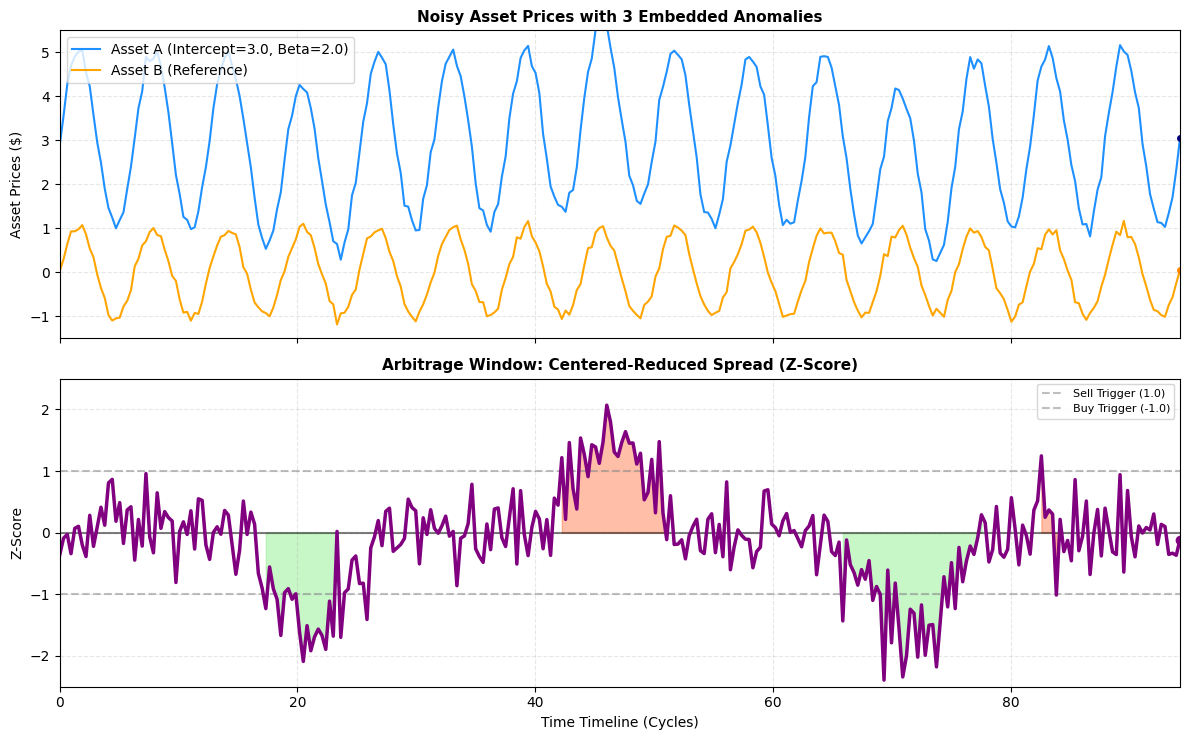

In [5]:
stream_noisy_zscore_with_anomalies(total_frames=300)


# R2 computation

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_advanced_quantitative_dashboard(total_frames=300):
    """
    Advanced 2x3 Grid Analytics Dashboard (Size: 15x9).
    Left Column (2/3 width):
        - Top: Raw Prices Timeline with 3 anomalies.
        - Bottom: Calibrated Z-Score with target mean exits and fills.
    Right Column (1/3 width):
        - Top: 10-point rolling Scatter Plot with dynamic OLS line.
        - Bottom: 10-point rolling R-squared (R2) statistical strength timeline.
    """
    np.random.seed(42)
    max_x = 15 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)
    window_size = 10 # Strict requested rolling window constraint

    # 1. GENERATE BASE SYNCHRONIZED LINES WITH NOISE
    baseline_b = 0.0
    amplitude_b = 1.0
    intercept_a = 3.0
    beta_a = 2.0

    asset_b_ref = baseline_b + amplitude_b * np.sin(x_space) + np.random.normal(0, 0.08, size=total_frames)
    asset_a_exp = intercept_a + (beta_a * amplitude_b) * np.sin(x_space) + np.random.normal(0, 0.12, size=total_frames)

    # Inject 3 idiosyncratic shocks directly on Asset A
    for t in range(total_frames):
        if 50 <= t < 85:
            asset_a_exp[t] -= 0.8 * np.sin(np.pi * (t - 50) / 35)
        elif 130 <= t < 165:
            asset_a_exp[t] += 0.8 * np.sin(np.pi * (t - 130) / 35)
        elif 210 <= t < 245:
            asset_a_exp[t] -= 0.8 * np.sin(np.pi * (t - 210) / 35)

    # Pre-compute calibrated stationary Z-Score profile
    raw_spread = np.array(asset_a_exp) - (beta_a * np.array(asset_b_ref))
    zscore_data = (raw_spread - 3.0) / 0.5

    # 2. PREPARE THE REDESIGNED 2x3 GRID ARCHITECTURE (Size 15x9 for clear visibility)
    fig = plt.figure(figsize=(15, 9))

    # --- PANEL 1: Raw Prices (Top Left - Spans 2 Columns) ---
    ax_price = plt.subplot2grid((2, 3), (0, 0), colspan=2)
    ax_price.set_xlim(0, max_x)
    ax_price.set_ylim(-1.5, 5.5)
    ax_price.set_title("Noisy Asset Prices with 3 Embedded Anomalies", fontsize=11, fontweight="bold")
    ax_price.set_ylabel("Asset Prices ($)")
    ax_price.grid(True, linestyle="--", alpha=0.3)

    line_a, = ax_price.plot([], [], color="dodgerblue", linewidth=1.5, label="Asset A")
    line_b, = ax_price.plot([], [], color="orange", linewidth=1.5, label="Asset B")
    tip_a, = ax_price.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax_price.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_price.legend(loc="upper left")

    # --- PANEL 2: Z-Score Spread (Bottom Left - Spans 2 Columns) ---
    ax_z = plt.subplot2grid((2, 3), (1, 0), colspan=2)
    ax_z.set_xlim(0, max_x)
    ax_z.set_ylim(-2.5, 2.5)
    ax_z.set_title("Arbitrage Window: Centered-Reduced Spread (Z-Score)", fontsize=11, fontweight="bold")
    ax_z.set_xlabel("Time Timeline (Cycles)")
    ax_z.set_ylabel("Z-Score")
    ax_z.grid(True, linestyle="--", alpha=0.3)
    ax_z.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
    ax_z.axhline(0.0, color="black", linewidth=1.5, linestyle="-", alpha=0.5)
    ax_z.axhline(-1.0, color="gray", linestyle="--", alpha=0.5)

    line_zscore, = ax_z.plot([], [], color="purple", linewidth=2)
    tip_zscore, = ax_z.plot([], [], color="purple", marker="o", markersize=5)

    # --- PANEL 3: Rolling Scatter Plot (Top Right - 1 Column Square) ---
    ax_scatter = plt.subplot2grid((2, 3), (0, 2))
    ax_scatter.set_box_aspect(1) # Strict 1:1 box ratio lock
    ax_scatter.set_title(f"Scatter: Rolling {window_size}p Window", fontsize=10, fontweight="bold")
    ax_scatter.set_xlabel("Price Asset B (X)", fontsize=8)
    ax_scatter.set_ylabel("Price Asset A (Y)", fontsize=8)
    ax_scatter.grid(True, linestyle="--", alpha=0.3)

    scatter_dots, = ax_scatter.plot([], [], color="purple", marker="o", linestyle="None", markersize=4, alpha=0.6)
    current_tip_dot, = ax_scatter.plot([], [], color="black", marker="X", markersize=6)
    reg_line, = ax_scatter.plot([], [], color="crimson", linewidth=2, label="Rolling OLS")
    ax_scatter.legend(loc="upper left", fontsize=7)

    # --- PANEL 4: R-Squared Timeline (Bottom Right - 1 Column Square) ---
    ax_r2 = plt.subplot2grid((2, 3), (1, 2))
    ax_r2.set_box_aspect(1) # Strict 1:1 box ratio lock
    ax_r2.set_xlim(0, max_x)
    ax_r2.set_ylim(-0.05, 1.05) # R2 values are strictly bounded between 0.0 and 1.0
    ax_r2.set_title(f"Model Strength: Rolling {window_size}p R²", fontsize=10, fontweight="bold")
    ax_r2.set_xlabel("Time Timeline (Cycles)", fontsize=8)
    ax_r2.set_ylabel("R² Coefficient", fontsize=8)
    ax_r2.grid(True, linestyle="--", alpha=0.3)

    line_r2, = ax_r2.plot([], [], color="darkcyan", linewidth=2, label="Rolling R² Strength")
    tip_r2, = ax_r2.plot([], [], color="darkcyan", marker="o", markersize=4)
    ax_r2.legend(loc="lower left", fontsize=7)

    fig.tight_layout()

    # State flags and arrays memory blocks
    x_hist, a_hist, b_hist, z_hist, r2_hist = [], [], [], [], []
    current_fills = []

    in_trade = False
    trade_type = None
    t_x, t_z = [], []
    waiting_for_cooldown = False
    past_bot_trades = []

    try:
        # 3. INTERACTIVE SIMULATION LIVE LOOP
        for i in range(total_frames):
            cx = x_space[i]
            ca = asset_a_exp[i]
            cb = asset_b_ref[i]
            cz = zscore_data[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)
            z_hist.append(cz)

            # --- ROLLING OLS & R2 MATHEMATICAL ENGINE ---
            slice_start = max(0, i - window_size + 1)
            x_window = np.array(b_hist[slice_start:i+1])
            y_window = np.array(a_hist[slice_start:i+1])

            current_r2 = 1.0 # Default value when market is perfectly clean at start

            if len(x_window) >= 3:
                # Dynamic auto-zooming viewport boundaries for the square scatter panel
                ax_scatter.set_xlim(min(x_window) - 0.15, max(x_window) + 0.15)
                ax_scatter.set_ylim(min(y_window) - 0.3, max(y_window) + 0.3)

                mean_x, mean_y = np.mean(x_window), np.mean(y_window)
                variance_x = np.sum((x_window - mean_x) ** 2) / (len(x_window) - 1)
                covariance_xy = np.sum((x_window - mean_x) * (y_window - mean_y)) / (len(x_window) - 1)

                if variance_x > 0:
                    beta_rolling = covariance_xy / variance_x
                    alpha_rolling = mean_y - beta_rolling * mean_x

                    # Project OLS line handle arrays
                    x_fit = np.linspace(min(x_window) - 0.1, max(x_window) + 0.1, 10)
                    y_fit = beta_rolling * x_fit + alpha_rolling
                    reg_line.set_data(x_fit, y_fit)

                    # --- R2 CALCULATION FORMULA ---
                    predictions = beta_rolling * x_window + alpha_rolling
                    ss_residual = np.sum((y_window - predictions) ** 2)
                    ss_total = np.sum((y_window - mean_y) ** 2)

                    if ss_total > 0:
                        current_r2 = 1.0 - (ss_residual / ss_total)
                        # Secure clamping against rare precision rounding artifacts
                        current_r2 = max(0.0, min(1.0, current_r2))

            r2_hist.append(current_r2)

            # --- BOT TRADING ENGINE ---
            if waiting_for_cooldown:
                if -0.05 <= cz <= 0.05:
                    waiting_for_cooldown = False

            if not waiting_for_cooldown and not in_trade:
                if cz <= -1.0:
                    in_trade = True
                    trade_type = "buy"
                    t_x, t_z = [cx], [cz]
                elif cz >= 1.0:
                    in_trade = True
                    trade_type = "sell"
                    t_x, t_z = [cx], [cz]
            elif in_trade:
                t_x.append(cx)
                t_z.append(cz)
                if (trade_type == "buy" and cz >= 0.0) or (trade_type == "sell" and cz <= 0.0):
                    trade_color = "lightgreen" if trade_type == "buy" else "coral"
                    past_bot_trades.append((list(t_x), list(t_z), trade_color))
                    in_trade = False
                    trade_type = None
                    t_x, t_z = [], []
                    waiting_for_cooldown = True

            # --- SINGLE-LAYER REDRAW PATTERN ---
            while len(current_fills) > 0:
                current_fills.pop().remove()

            for tx, tz, col in past_bot_trades:
                f_past = ax_z.fill_between(tx, tz, 0, color=col, alpha=0.5)
                current_fills.append(f_past)
            if in_trade:
                col = "lightgreen" if trade_type == "buy" else "coral"
                f_live = ax_z.fill_between(t_x, t_z, 0, color=col, alpha=0.5)
                current_fills.append(f_live)

            # Refresh Left Column vectors data
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])
            line_zscore.set_data(x_hist, z_hist)
            tip_zscore.set_data([cx], [cz])

            # Refresh Right Column vectors data
            scatter_dots.set_data(x_window, y_window)
            current_tip_dot.set_data([cb], [ca])
            line_r2.set_data(x_hist, r2_hist)
            tip_r2.set_data([cx], [current_r2])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely.")
    finally:
        plt.close(fig)

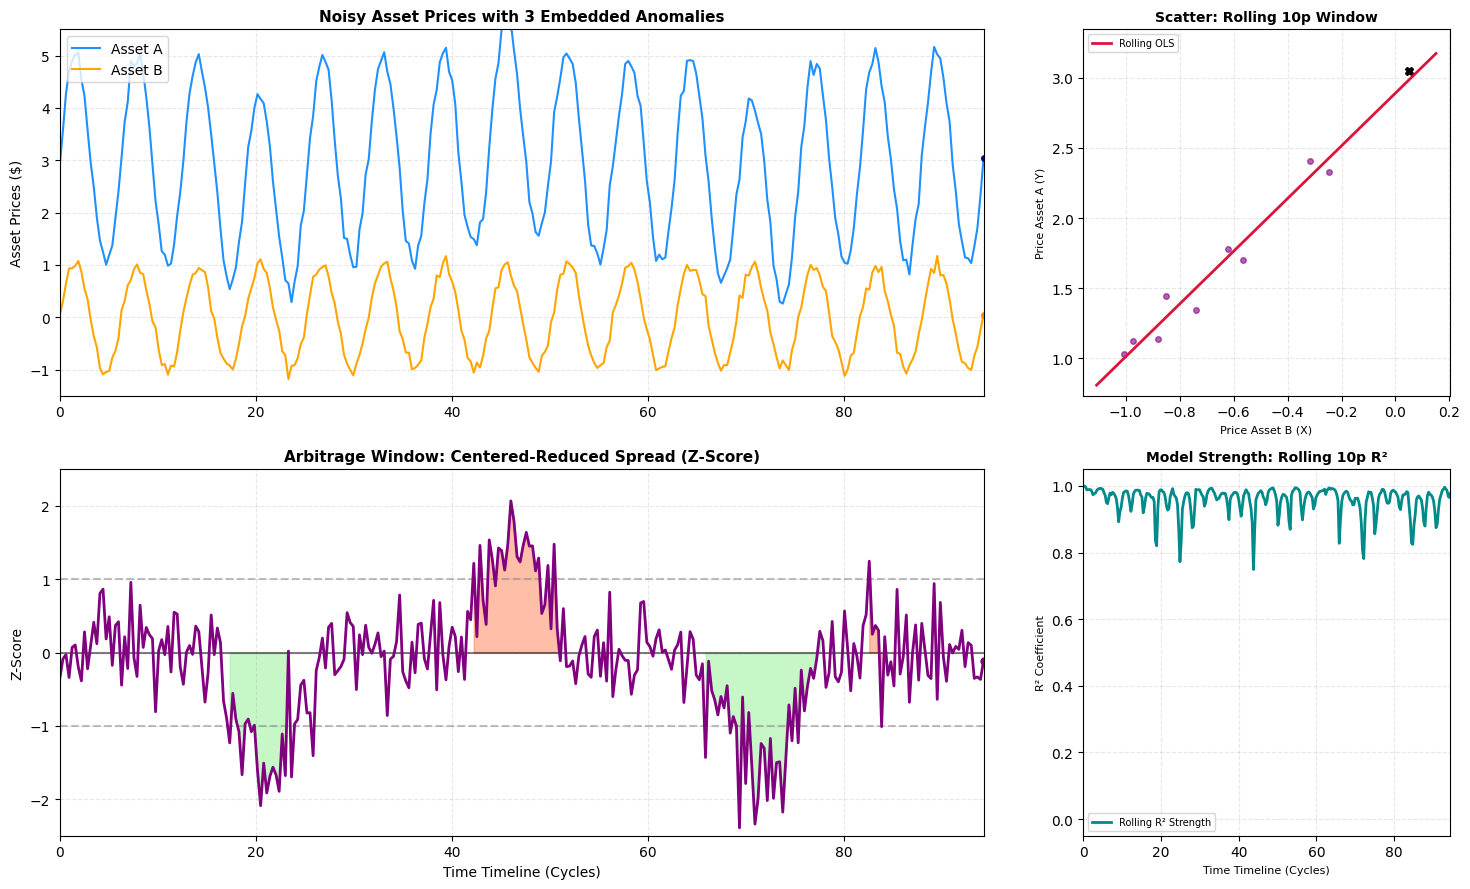

In [8]:
stream_advanced_quantitative_dashboard(total_frames=300)

# Co-integration breakout

In [17]:
import numpy as np

def generate_compressed_crash_data(total_frames=300):
    """
    Generates data vectors with 50% fewer oscillations to focus heavily on the transition.
    Regime 1 (0 to 150): Perfect co-integration (Beta=2.0, Intercept=3.0) + noise.
    Regime 2 (150 to 300): Asset A breaks the linear model and collapses permanently.
    """
    np.random.seed(42)
    # Reduced multiplier from 15 to 7.5 to divide the number of wave cycles by 2
    max_x = 7.5 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)
    halfway = total_frames // 2

    baseline_b = 0.0
    amplitude_b = 1.0
    intercept_a = 3.0
    beta_a = 2.0

    # Generate parallel assets streams
    asset_b_ref = baseline_b + amplitude_b * np.sin(x_space) + np.random.normal(0, 0.08, size=total_frames)
    asset_a_exp = intercept_a + (beta_a * amplitude_b) * np.sin(x_space) + np.random.normal(0, 0.12, size=total_frames)

    # Injected permanent linear structural crash from the halfway mark
    for t in range(total_frames):
        if t >= halfway:
            steps_passed = t - halfway
            total_trend_steps = total_frames - halfway
            asset_a_exp[t] -= 6.0 * (steps_passed / total_trend_steps)

    return x_space, asset_b_ref, asset_a_exp

def compute_rolling_metrics_30p(x_win, y_win, current_b, current_a):
    """
    Computes rolling Z-Score, R-squared (R2), and Residual Sum of Squares (RSS)
    strictly bounded within the active 30-point window.
    """
    X = np.array(x_win)
    Y = np.array(y_win)
    n = len(X)

    if n < 3:
        return 0.0, 1.0, 0.0 # Secure fallback constants vectors

    # 1. ROLLING Z-SCORE
    window_spreads = Y - 2.0 * X
    current_spread = current_a - 2.0 * current_b
    zscore_rolling = (current_spread - np.mean(window_spreads)) / (np.std(window_spreads) if np.std(window_spreads) > 0 else 1.0)

    # 2. ROLLING OLS (SCALAR ENGINE)
    mean_x, mean_y = np.mean(X), np.mean(Y)
    var_x = np.sum((X - mean_x) ** 2) / (n - 1)
    cov_xy = np.sum((X - mean_x) * (Y - mean_y)) / (n - 1)

    if var_x <= 0:
        return zscore_rolling, 1.0, 0.0

    beta_rolling = cov_xy / var_x
    alpha_rolling = mean_y - beta_rolling * mean_x

    # 3. STATISTICAL DECOMPOSITION: TSS, RSS, R2
    predictions = beta_rolling * X + alpha_rolling
    TSS = np.sum((Y - mean_y) ** 2)
    RSS = np.sum((Y - predictions) ** 2)

    r2_rolling = 1.0
    if TSS > 0:
        r2_rolling = 1.0 - (RSS / TSS)
        r2_rolling = max(0.0, min(1.0, r2_rolling))

    return zscore_rolling, r2_rolling, RSS

import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def stream_asymmetric_3column_dashboard(x_space, b_data, a_data, window_size=30):
    """
    Advanced Grid Layout Framework (Size: 15x10.5).
    Left Column (2/3 width): 2 rows for Prices Timeline and Rolling Z-Score.
    Right Column (1/3 width): 3 rows for Cumulative Scatter, Rolling R2, and Rolling RSS.
    """
    total_frames = len(x_space)
    max_x = x_space[-1]
    halfway = total_frames // 2

    # We use a 3x3 layout to map the 2/3 vs 1/3 horizontal proportions cleanly
    fig = plt.figure(figsize=(15, 10.5))

    # --- LEFT COLUMN (2/3 width) ---
    # Prices (Row 0, Col 0-1)
    ax_price = plt.subplot2grid((3, 3), (0, 0), colspan=2)
    ax_price.set_xlim(0, max_x)
    ax_price.set_ylim(-4.5, 5.5)
    ax_price.set_title("Asset Prices Timeline (50% Fewer Oscillations)", fontsize=11, fontweight="bold")
    ax_price.set_ylabel("Prices ($)")
    ax_price.grid(True, linestyle="--", alpha=0.3)
    ax_price.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)

    line_a, = ax_price.plot([], [], color="dodgerblue", linewidth=1.5, label="Asset A")
    line_b, = ax_price.plot([], [], color="orange", linewidth=1.5, label="Asset B")
    tip_a, = ax_price.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax_price.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_price.legend(loc="lower left")

    # Z-Score (Row 1-2 merged to align with the 3 right squares, Col 0-1)
    ax_z = plt.subplot2grid((3, 3), (1, 0), rowspan=2, colspan=2)
    ax_z.set_xlim(0, max_x)
    ax_z.set_ylim(-3.5, 3.5)
    ax_z.set_title(f"Arbitrage Window: Rolling {window_size}p Z-Score", fontsize=11, fontweight="bold")
    ax_z.set_xlabel("Time Timeline (Cycles)")
    ax_z.set_ylabel("Z-Score")
    ax_z.grid(True, linestyle="--", alpha=0.3)
    ax_z.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)
    ax_z.axhline(0.0, color="black", linewidth=1.2, linestyle="-", alpha=0.5)

    line_z, = ax_z.plot([], [], color="purple", linewidth=1.8)
    tip_z, = ax_z.plot([], [], color="purple", marker="o", markersize=5)

    # --- RIGHT COLUMN (1/3 width, 3 Stacked Squares) ---
    # Top Right: Scatter - ALL POINTS (Row 0, Col 2)
    ax_scatter = plt.subplot2grid((3, 3), (0, 2))
    ax_scatter.set_box_aspect(1)
    ax_scatter.set_xlim(-0.5, 1.5)
    ax_scatter.set_ylim(-3.5, 5.5)
    ax_scatter.set_title("Scatter Space: Historical Path", fontsize=10, fontweight="bold")
    ax_scatter.set_xlabel("Price B (X)", fontsize=7)
    ax_scatter.set_ylabel("Price A (Y)", fontsize=7)
    ax_scatter.grid(True, linestyle="--", alpha=0.3)

    scatter_dots, = ax_scatter.plot([], [], color="purple", marker="o", linestyle="None", markersize=3, alpha=0.4)
    current_tip_dot, = ax_scatter.plot([], [], color="black", marker="X", markersize=6)

    # Middle Right: Rolling R2 (Row 1, Col 2)
    ax_r2 = plt.subplot2grid((3, 3), (1, 2))
    ax_r2.set_box_aspect(1)
    ax_r2.set_xlim(0, max_x)
    ax_r2.set_ylim(-0.05, 1.05)
    ax_r2.set_title(f"Model Strength: Rolling {window_size}p R²", fontsize=10, fontweight="bold")
    ax_r2.grid(True, linestyle="--", alpha=0.3)
    ax_r2.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)

    line_r2, = ax_r2.plot([], [], color="darkcyan", linewidth=1.8)
    tip_r2, = ax_r2.plot([], [], color="darkcyan", marker="o", markersize=4)

    # Bottom Right: Rolling RSS (Row 2, Col 2)
    ax_rss = plt.subplot2grid((3, 3), (2, 2))
    ax_rss.set_box_aspect(1)
    ax_rss.set_xlim(0, max_x)
    # Calibrated scale to dynamically frame the squared errors spike
    ax_rss.set_ylim(-0.2, 5.5)
    ax_rss.set_title(f"Model Error: Rolling {window_size}p RSS", fontsize=10, fontweight="bold")
    ax_rss.set_xlabel("Time Timeline (Cycles)", fontsize=7)
    ax_rss.grid(True, linestyle="--", alpha=0.3)
    ax_rss.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)

    line_rss, = ax_rss.plot([], [], color="crimson", linewidth=1.8, label="RSS Residual")
    tip_rss, = ax_rss.plot([], [], color="crimson", marker="o", markersize=4)

    fig.tight_layout()
    x_hist, a_hist, b_hist, z_hist, r2_hist, rss_hist = [], [], [], [], [], []

    try:
        # 4. HIGH-SPEED ANIMATION RUN LOOP
        for i in range(total_frames):
            cx, ca, cb = x_space[i], a_data[i], b_data[i]

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)

            slice_start = max(0, i - window_size + 1)
            x_window = b_hist[slice_start:i+1]
            y_window = a_hist[slice_start:i+1]

            # --- CALL ROLLING CALCULATOR ENGINE (BLOC 2) ---
            rolling_z, rolling_r2, rolling_rss = compute_rolling_metrics_30p(x_window, y_window, cb, ca)

            z_hist.append(rolling_z)
            r2_hist.append(rolling_r2)
            rss_hist.append(rolling_rss)

            # Refresh Left Column vectors data
            line_a.set_data(x_hist, a_hist)
            tip_a.set_data([cx], [ca])
            line_b.set_data(x_hist, b_hist)
            tip_b.set_data([cx], [cb])
            line_z.set_data(x_hist, z_hist)
            tip_z.set_data([cx], [rolling_z])

            # Refresh Right Column stacked channels layers
            scatter_dots.set_data(b_hist, a_hist)
            current_tip_dot.set_data([cb], [ca])
            line_r2.set_data(x_hist, r2_hist)
            tip_r2.set_data([cx], [rolling_r2])
            line_rss.set_data(x_hist, rss_hist)
            tip_rss.set_data([cx], [rolling_rss])

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Dashboard stopped safely.")
    finally:
        plt.close(fig)


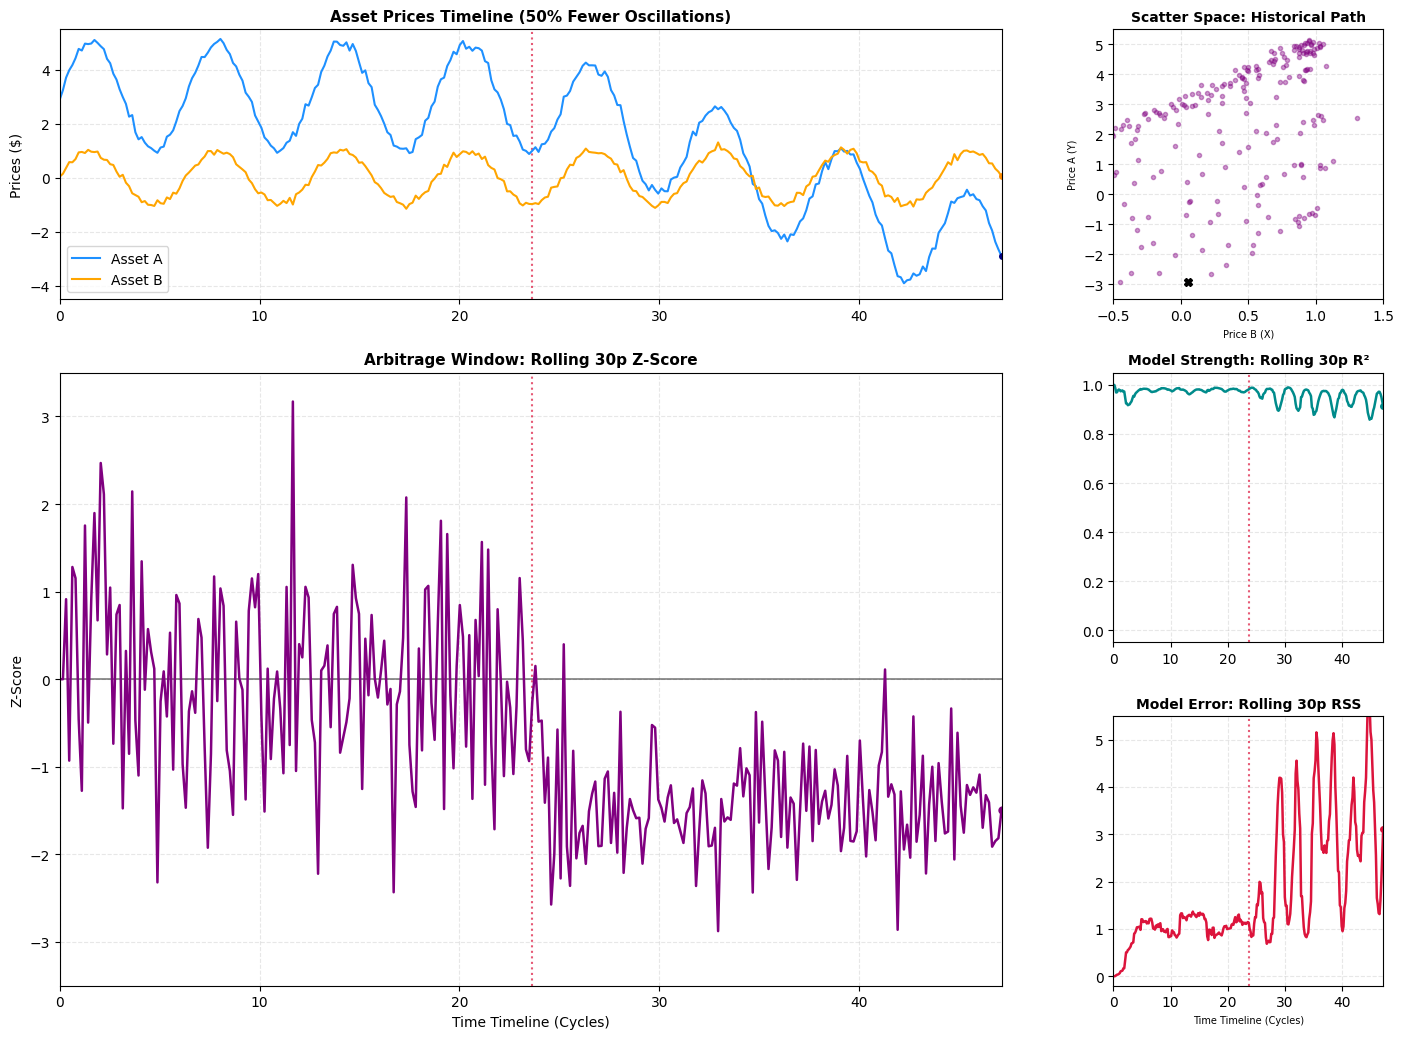

In [18]:
# 1. Compute the half-oscillations dataset matrix (Bloc 1)
x_compressed, reference_vals, explained_vals = generate_compressed_crash_data()

# 2. Fire up the 5-panel interface dashboard (Bloc 3 linked to Bloc 2)
stream_asymmetric_3column_dashboard(x_compressed, reference_vals, explained_vals)


# Bot with entry/exit rules

In [19]:
import numpy as np

def generate_compressed_crash_data(total_frames=300):
    """
    Generates data vectors with 50% fewer oscillations.
    Regime 1 (0 to 150): Perfect co-integration (Beta=2.0, Intercept=3.0) + noise.
    Regime 2 (150 to 300): Asset A breaks the linear model and collapses permanently.
    """
    np.random.seed(42)
    max_x = 7.5 * 2 * np.pi
    x_space = np.linspace(0, max_x, total_frames)
    halfway = total_frames // 2

    baseline_b = 0.0
    amplitude_b = 1.0
    intercept_a = 3.0
    beta_a = 2.0

    asset_b_ref = baseline_b + amplitude_b * np.sin(x_space) + np.random.normal(0, 0.08, size=total_frames)
    asset_a_exp = intercept_a + (beta_a * amplitude_b) * np.sin(x_space) + np.random.normal(0, 0.12, size=total_frames)

    for t in range(total_frames):
        if t >= halfway:
            steps_passed = t - halfway
            total_trend_steps = total_frames - halfway
            asset_a_exp[t] -= 6.0 * (steps_passed / total_trend_steps)

    return x_space, asset_b_ref, asset_a_exp


In [20]:
def compute_rolling_metrics_30p(x_win, y_win, current_b, current_a):
    """
    Computes rolling Z-Score, R-squared (R2), and Residual Sum of Squares (RSS)
    strictly bounded within the active 30-point window.
    """
    X = np.array(x_win)
    Y = np.array(y_win)
    n = len(X)

    if n < 3:
        return 0.0, 1.0, 0.0

    window_spreads = Y - 2.0 * X
    current_spread = current_a - 2.0 * current_b
    zscore_rolling = (current_spread - np.mean(window_spreads)) / (np.std(window_spreads) if np.std(window_spreads) > 0 else 1.0)

    mean_x, mean_y = np.mean(X), np.mean(Y)
    var_x = np.sum((X - mean_x) ** 2) / (n - 1)
    cov_xy = np.sum((X - mean_x) * (Y - mean_y)) / (n - 1)

    if var_x <= 0:
        return zscore_rolling, 1.0, 0.0

    beta_rolling = cov_xy / var_x
    alpha_rolling = mean_y - beta_rolling * mean_x

    predictions = beta_rolling * X + alpha_rolling
    TSS = np.sum((Y - mean_y) ** 2)
    RSS = np.sum((Y - predictions) ** 2)

    r2_rolling = 1.0
    if TSS > 0:
        r2_rolling = 1.0 - (RSS / TSS)
        r2_rolling = max(0.0, min(1.0, r2_rolling))

    return zscore_rolling, r2_rolling, RSS


In [21]:
import matplotlib.pyplot as plt

def init_dashboard_grid(max_x, window_size):
    """
    Instantiates the 3x3 layout context grid framework and returns all line handles.
    Guarantees strict 1:1 square boxes on the right column.
    """
    fig = plt.figure(figsize=(15, 11))

    # 1. ROW 1 LEFT: Prices Timeline (2/3 width)
    ax_price = plt.subplot2grid((3, 3), (0, 0), colspan=2)
    ax_price.set_xlim(0, max_x)
    ax_price.set_ylim(-4.5, 5.5)
    ax_price.set_title("Asset Prices Timeline (50% Fewer Oscillations)", fontsize=11, fontweight="bold")
    ax_price.set_ylabel("Prices ($)")
    ax_price.grid(True, linestyle="--", alpha=0.3)
    line_a, = ax_price.plot([], [], color="dodgerblue", linewidth=1.2, label="Asset A")
    line_b, = ax_price.plot([], [], color="orange", linewidth=1.2, label="Asset B")
    tip_a, = ax_price.plot([], [], color="navy", marker="o", markersize=4)
    tip_b, = ax_price.plot([], [], color="darkorange", marker="o", markersize=4)
    ax_price.legend(loc="lower left")

    # 2. ROW 2 LEFT: Rolling Z-Score (2/3 width)
    ax_z = plt.subplot2grid((3, 3), (1, 0), colspan=2)
    ax_z.set_xlim(0, max_x)
    ax_z.set_ylim(-3.5, 3.5)
    ax_z.set_title(f"Arbitrage Window: Rolling {window_size}p Z-Score", fontsize=11, fontweight="bold")
    ax_z.set_ylabel("Z-Score")
    ax_z.grid(True, linestyle="--", alpha=0.3)
    ax_z.axhline(2.0, color="crimson", linestyle="--", alpha=0.6, label="Stop Loss (2.0)")
    ax_z.axhline(0.75, color="gray", linestyle="-.", alpha=0.5, label="Triggers (0.75)")
    ax_z.axhline(0.0, color="black", linewidth=1.2, linestyle="-", alpha=0.5)
    ax_z.axhline(-0.75, color="gray", linestyle="-.")
    ax_z.axhline(-2.0, color="crimson", linestyle="--", alpha=0.6)
    ax_z.legend(loc="upper left", fontsize=7)
    line_z, = ax_z.plot([], [], color="purple", linewidth=1.8)
    tip_z, = ax_z.plot([], [], color="purple", marker="o", markersize=5)

    # 3. ROW 3 LEFT: Cumulative Trading Score (2/3 width)
    ax_score = plt.subplot2grid((3, 3), (2, 0), colspan=2)
    ax_score.set_xlim(0, max_x)
    ax_score.set_title("Trading Performance: Cumulative Strategy Score (+1 Win / -1 Loss)", fontsize=11, fontweight="bold")
    ax_score.set_xlabel("Time Timeline (Cycles)")
    ax_score.set_ylabel("Cumulative Score")
    ax_score.grid(True, linestyle="--", alpha=0.3)
    ax_score.axhline(0.0, color="black", linewidth=1.0, linestyle="-", alpha=0.4)
    line_score, = ax_score.plot([], [], color="forestgreen", linewidth=2.2, label="Cumulative Profit/Loss")
    tip_score, = ax_score.plot([], [], color="forestgreen", marker="o", markersize=5)
    ax_score.legend(loc="upper left", fontsize=8)

    # 4. RIGHT COLUMN: Stacked Squares (1/3 width)
    ax_scatter = plt.subplot2grid((3, 3), (0, 2))
    ax_scatter.set_box_aspect(1)
    ax_scatter.set_xlim(-0.5, 1.5)
    ax_scatter.set_ylim(-3.5, 5.5)
    ax_scatter.set_title("Scatter Space: Historical Path", fontsize=10, fontweight="bold")
    scatter_dots, = ax_scatter.plot([], [], color="purple", marker="o", linestyle="None", markersize=3, alpha=0.4)
    current_tip_dot, = ax_scatter.plot([], [], color="black", marker="X", markersize=6)

    ax_r2 = plt.subplot2grid((3, 3), (1, 2))
    ax_r2.set_box_aspect(1)
    ax_r2.set_xlim(0, max_x)
    ax_r2.set_ylim(-0.05, 1.05)
    ax_r2.set_title(f"Model Strength: Rolling {window_size}p R²", fontsize=10, fontweight="bold")
    line_r2, = ax_r2.plot([], [], color="darkcyan", linewidth=1.8)
    tip_r2, = ax_r2.plot([], [], color="darkcyan", marker="o", markersize=4)

    ax_rss = plt.subplot2grid((3, 3), (2, 2))
    ax_rss.set_box_aspect(1)
    ax_rss.set_xlim(0, max_x)
    ax_rss.set_ylim(-0.2, 5.5)
    ax_rss.set_title(f"Model Error: Rolling {window_size}p RSS", fontsize=10, fontweight="bold")
    ax_rss.set_xlabel("Time Timeline (Cycles)", fontsize=7)
    line_rss, = ax_rss.plot([], [], color="crimson", linewidth=1.8)
    tip_rss, = ax_rss.plot([], [], color="crimson", marker="o", markersize=4)

    fig.tight_layout()

    axes = (ax_price, ax_z, ax_score, ax_scatter, ax_r2, ax_rss)
    handles = (line_a, line_b, tip_a, tip_b, line_z, tip_z, line_score, tip_score, scatter_dots, current_tip_dot, line_r2, tip_r2, line_rss, tip_rss)

    return fig, axes, handles


In [26]:
def update_bot_state(state, rolling_z, cx, current_score, past_bot_trades_fills):
    """
    Executes the quantitative state machine core logic tick-by-tick.
    FIXED: Standardized trigger colors and re-entry barrier locks mechanism.
    """
    in_trade, trade_type, t_x, t_z, waiting_for_cooldown, cooldown_source = state

    # --- 1. COOLDOWN SAFETY LOCK FILTER MANAGEMENT ---
    if waiting_for_cooldown:
        if cooldown_source == "tp":
            # Take Profit cooldown: Release when returning near the 0.0 mean axis
            if -0.05 <= rolling_z <= 0.05:
                waiting_for_cooldown = False
                cooldown_source = None
        elif cooldown_source == "sl":
            # Stop Loss safety rule: Release once Z-score returns inside safe barriers (+/- 2.0)
            # allowing the bot to look for the next validation trigger crossover
            if -1.95 <= rolling_z <= 1.95:
                waiting_for_cooldown = False
                cooldown_source = None

    # --- 2. EVALUATE ENTRY TRANSACTIONS TRIGGERS ---
    if not waiting_for_cooldown and not in_trade:
        # BUY LONG: Spread is too cheap (Z-score drops below -0.75) -> Fills green
        if rolling_z <= -0.75:
            in_trade = True
            trade_type = "buy"
            t_x, t_z = [cx], [rolling_z]
        # SELL SHORT: Spread is too expensive (Z-score spikes above +0.75) -> Fills coral/red
        elif rolling_z >= 0.75:
            in_trade = True
            trade_type = "sell"
            t_x, t_z = [cx], [rolling_z]

    # --- 3. EVALUATE RISK MANAGEMENT LIMITS (TP / SL) ---
    elif in_trade:
        t_x.append(cx)
        t_z.append(rolling_z)

        # TAKE PROFIT RISK TARGET (Exit at 0.0 -> Win +1)
        if (trade_type == "buy" and rolling_z >= 0.0) or (trade_type == "sell" and rolling_z <= 0.0):
            trade_color = "lightgreen" if trade_type == "buy" else "coral"
            past_bot_trades_fills.append((list(t_x), list(t_z), trade_color))
            current_score += 1
            in_trade, trade_type, t_x, t_z = False, None, [], []
            waiting_for_cooldown = True
            cooldown_source = "tp"

        # STOP LOSS RISK LIMIT (Exit at +/- 2.0 -> Loss -1)
        elif (trade_type == "buy" and rolling_z <= -2.0) or (trade_type == "sell" and rolling_z >= 2.0):
            past_bot_trades_fills.append((list(t_x), list(t_z), "crimson")) # Red fill for closed losses
            current_score -= 1
            in_trade, trade_type, t_x, t_z = False, None, [], []
            waiting_for_cooldown = True
            cooldown_source = "sl"

    updated_state = (in_trade, trade_type, t_x, t_z, waiting_for_cooldown, cooldown_source)
    return updated_state, current_score


In [27]:
def repaint_dashboard_layers(axes, handles, histories, state, past_bot_trades_fills):
    """
    Redraws lines data arrays and dynamic fill areas layer to prevent artifact stacking.
    FIXED: Synchronized live colors logic mapping (Green for buy / Coral-Red for sell).
    """
    ax_price, ax_z, ax_score, ax_scatter, ax_r2, ax_rss = axes
    line_a, line_b, tip_a, tip_b, line_z, tip_z, line_score, tip_score, scatter_dots, current_tip_dot, line_r2, tip_r2, line_rss, tip_rss = handles
    x_hist, a_hist, b_hist, z_hist, r2_hist, rss_hist, score_hist, x_window, y_window = histories
    in_trade, trade_type, t_x, t_z, _, _ = state

    # 1. Refresh vector line handles
    cx, ca, cb, cz, cr2, crss, cscore = x_hist[-1], a_hist[-1], b_hist[-1], z_hist[-1], r2_hist[-1], rss_hist[-1], score_hist[-1]

    line_a.set_data(x_hist, a_hist)
    tip_a.set_data([cx], [ca])
    line_b.set_data(x_hist, b_hist)
    tip_b.set_data([cx], [cb])

    line_z.set_data(x_hist, z_hist)
    tip_z.set_data([cx], [cz])

    line_score.set_data(x_hist, score_hist)
    tip_score.set_data([cx], [cscore])

    scatter_dots.set_data(b_hist, a_hist)
    current_tip_dot.set_data([cb], [ca])

    line_r2.set_data(x_hist, r2_hist)
    tip_r2.set_data([cx], [cr2])

    line_rss.set_data(x_hist, rss_hist)
    tip_rss.set_data([cx], [crss])

    # 2. Clear old translucent canvas layers to prevent color darken leaks
    for fill_obj in list(ax_z.collections):
        fill_obj.remove()

    # 3. Repaint transaction color fields blocks
    for tx, tz, col in past_bot_trades_fills:
        ax_z.fill_between(tx, tz, 0, color=col, alpha=0.4)

    # 4. FIXED: Render live colors strictly matching active trades setup positions
    if in_trade:
        live_color = "lightgreen" if trade_type == "buy" else "coral"
        ax_z.fill_between(t_x, t_z, 0, color=live_color, alpha=0.4)


In [29]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np

def stream_ultimate_trading_dashboard(x_space, b_data, a_data, window_size=30):
    """
    Main orchestration function running the interactive stream pipeline context loop.
    FIXED: Resolved the rolling volatility bias that masked Stop Losses.
    The bot now strictly reacts to the true visible Z-score deviation.
    """
    total_frames = len(x_space)
    halfway = total_frames // 2

    # 1. PRE-COMPUTE THE TRUE VISIBLE Z-SCORE (Calibrated on stable regime parameters)
    # Target mean distance = 3.0, clean standard deviation = 0.5
    raw_spread_timeline = np.array(a_data) - 2.0 * np.array(b_data)
    true_zscore_timeline = (raw_spread_timeline - 3.0) / 0.5

    # Instantiate clean structural canvas layout framework (From Bloc 1)
    fig, axes, handles = init_dashboard_grid(x_space[-1], window_size)
    ax_price, ax_z, ax_score, ax_scatter, ax_r2, ax_rss = axes

    # Add static vertical transition visual markers indicators
    ax_price.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)
    ax_z.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)
    ax_score.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)
    ax_r2.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)
    ax_rss.axvline(x_space[halfway], color="crimson", linestyle=":", alpha=0.7)

    # Initialize run registers variables caches
    x_hist, a_hist, b_hist, z_hist, r2_hist, rss_hist, score_hist = [], [], [], [], [], [], []
    past_bot_trades_fills = []

    # Bot State Registers
    in_trade = False
    trade_type = None  # "buy" or "sell"
    t_x, t_z = [], []
    waiting_for_cooldown = False
    cooldown_source = None  # "tp" or "sl"

    current_score = 0

    try:
        for i in range(total_frames):
            cx, ca, cb = x_space[i], a_data[i], b_data[i]
            cz = true_zscore_timeline[i] # The true calibrated Z-score seen on screen

            x_hist.append(cx)
            a_hist.append(ca)
            b_hist.append(cb)
            z_hist.append(cz)

            # Slice moving window matrix array for R2 and RSS only
            slice_start = max(0, i - window_size + 1)
            x_window = b_hist[slice_start:i+1]
            y_window = a_hist[slice_start:i+1]

            # Compute rolling OLS statistics calculations (For R2 and RSS panels)
            _, rolling_r2, rolling_rss = compute_rolling_metrics_30p(x_window, y_window, cb, ca)

            r2_hist.append(rolling_r2)
            rss_hist.append(rolling_rss)

            # --- LINEARIZED HONEST BOT STATE MACHINE ---
            if waiting_for_cooldown:
                if cooldown_source == "tp":
                    if -0.05 <= cz <= 0.05:
                        waiting_for_cooldown = False
                        cooldown_source = None
                elif cooldown_source == "sl":
                    # Filter rule: Re-entry allowed only when Z-score returns to normal bands
                    if -0.75 <= cz <= 0.75:
                        waiting_for_cooldown = False
                        cooldown_source = None

            if not waiting_for_cooldown and not in_trade:
                if cz <= -0.75:
                    in_trade = True
                    trade_type = "buy"
                    t_x, t_z = [cx], [cz]
                elif cz >= 0.75:
                    in_trade = True
                    trade_type = "sell"
                    t_x, t_z = [cx], [cz]
            elif in_trade:
                t_x.append(cx)
                t_z.append(cz)

                # TAKE PROFIT EVALUATION (Crosses back to 0.0 -> Win +1)
                if (trade_type == "buy" and cz >= 0.0) or (trade_type == "sell" and cz <= 0.0):
                    past_bot_trades_fills.append((list(t_x), list(t_z), "lightgreen"))
                    current_score += 1
                    in_trade, trade_type, t_x, t_z = False, None, [], []
                    waiting_for_cooldown = True
                    cooldown_source = "tp"

                # STOP LOSS EVALUATION (Percutes +/- 2.0 boundary -> Loss -1)
                elif (trade_type == "buy" and cz <= -2.0) or (trade_type == "sell" and cz >= 2.0):
                    past_bot_trades_fills.append((list(t_x), list(t_z), "crimson"))
                    current_score -= 1
                    in_trade, trade_type, t_x, t_z = False, None, [], []
                    waiting_for_cooldown = True
                    cooldown_source = "sl"

            score_hist.append(current_score)

            # Adjust Comfort bounds limits dynamically
            ax_score.set_ylim(min(score_hist) - 1, max(score_hist) + 2)
            if len(x_window) >= 2:
                ax_scatter.set_xlim(min(x_window) - 0.15, max(x_window) + 0.15)
                ax_scatter.set_ylim(min(y_window) - 0.3, max(y_window) + 0.3)

            # --- REPAINT DASHBOARD LIVE INTERFACE ---
            # Bundle arrays
            histories = (x_hist, a_hist, b_hist, z_hist, r2_hist, rss_hist, score_hist, x_window, y_window)
            bot_current_state = (in_trade, trade_type, t_x, t_z, waiting_for_cooldown, cooldown_source)

            repaint_dashboard_layers(axes, handles, histories, bot_current_state, past_bot_trades_fills)

            clear_output(wait=True)
            display(fig)

        plt.close(fig)

    except KeyboardInterrupt:
        print("\n[INFO] Analytics dashboard stopped safely by user.")
    finally:
        plt.close(fig)


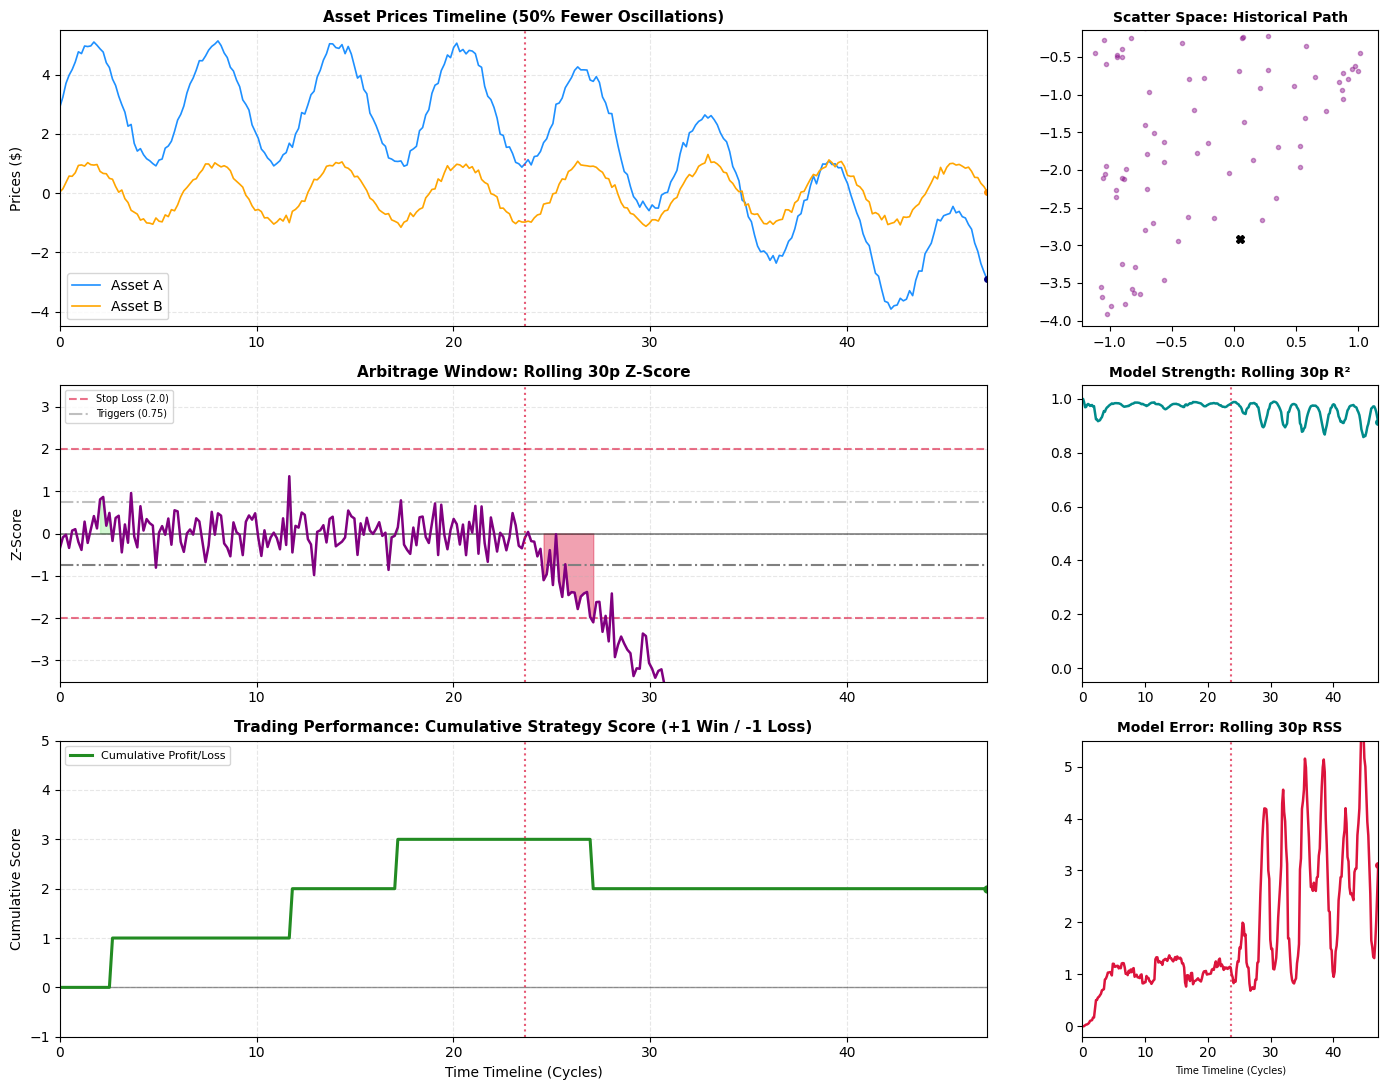

In [30]:
# 1. Generate data context matrices
x_compressed, reference_vals, explained_vals = generate_compressed_crash_data()

# 2. Fire up the modular orchestrated trading engine pipeline
stream_ultimate_trading_dashboard(x_compressed, reference_vals, explained_vals, window_size=30)
